<a href="https://colab.research.google.com/github/TejshreeRameshKarande/Deep_Learning/blob/main/Experiment_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install tensorflow matplotlib

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def create_model():
    model = tf.keras.models.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

In [ ]:
model_fixed = create_model()

model_fixed.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fixed = model_fixed.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=15,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9183 - loss: 0.2754 - val_accuracy: 0.9378 - val_loss: 0.2130
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9474 - loss: 0.1882 - val_accuracy: 0.9491 - val_loss: 0.1913
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9563 - loss: 0.1585 - val_accuracy: 0.9532 - val_loss: 0.1873
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9606 - loss: 0.1470 - val_accuracy: 0.9578 - val_loss: 0.1808
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9655 - loss: 0.1327 - val_accuracy: 0.9632 - val_loss: 0.1695
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9681 - loss: 0.1275 - val_accuracy: 0.9589 - val_loss: 0.1867
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9701 - loss: 0.1186 - val_accuracy: 0.9628 - val_loss: 0.1820
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9713 - loss: 0.1144 - 

In [ ]:
model_lr = create_model()

model_lr.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=2,
    verbose=1
)

history_lr = model_lr.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=15,
    callbacks=[lr_scheduler],
    verbose=1
)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9192 - loss: 0.2759 - val_accuracy: 0.9414 - val_loss: 0.2107 - learning_rate: 0.0100
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9497 - loss: 0.1849 - val_accuracy: 0.9536 - val_loss: 0.1724 - learning_rate: 0.0100
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9570 - loss: 0.1596 - val_accuracy: 0.9528 - val_loss: 0.1805 - learning_rate: 0.0100
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9607 - loss: 0.1513 - val_accuracy: 0.9605 - val_loss: 0.1689 - learning_rate: 0.0100
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9665 - loss: 0.1253 - val_accuracy: 0.9575 - val_loss: 0.1941 - learning_rate: 0.0100
Epoch 6/15
1498/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9679 - loss: 0.1203
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0009999999776482583.
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9659 - lo

In [ ]:
model_final = create_model()

model_final.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history_final = model_final.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=15,
    callbacks=[lr_scheduler, early_stop],
    verbose=1
)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9185 - loss: 0.2758 - val_accuracy: 0.9479 - val_loss: 0.1830 - learning_rate: 0.0100
Epoch 2/15
1494/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9507 - loss: 0.1745
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0009999999776482583.
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9499 - loss: 0.1797 - val_accuracy: 0.9537 - val_loss: 0.1801 - learning_rate: 0.0100
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9753 - loss: 0.0851 - val_accuracy: 0.9703 - val_loss: 0.1138 - learning_rate: 1.0000e-03
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9812 - loss: 0.0613 - val_accuracy: 0.9723 - val_loss: 0.1077 - learning_rate: 1.0000e-03
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9846 - loss: 0.0495 - val_accuracy: 0.9718 - val_loss: 0.1130 - learning_rate: 1.0000e-03
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy:

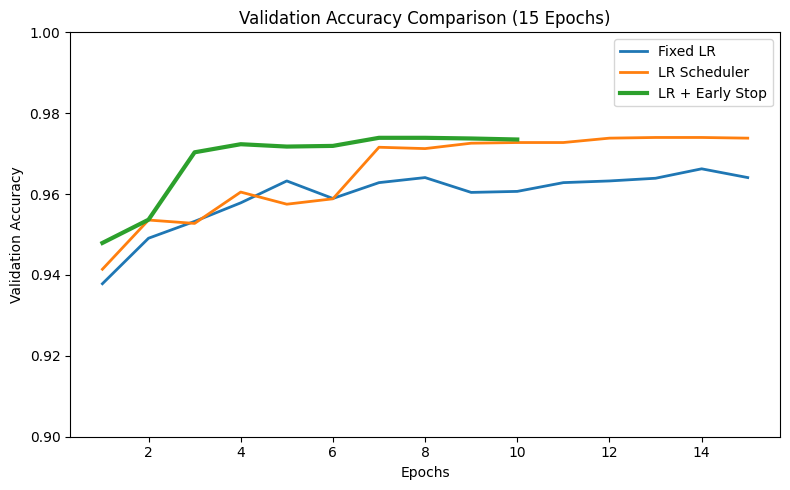

In [ ]:
plt.figure(figsize=(8,5))

epochs_fixed = range(1, len(history_fixed.history['val_accuracy'])+1)
epochs_lr = range(1, len(history_lr.history['val_accuracy'])+1)
epochs_final = range(1, len(history_final.history['val_accuracy'])+1)

plt.plot(epochs_fixed, history_fixed.history['val_accuracy'], linewidth=2, label="Fixed LR")
plt.plot(epochs_lr, history_lr.history['val_accuracy'], linewidth=2, label="LR Scheduler")
plt.plot(epochs_final, history_final.history['val_accuracy'], linewidth=3, label="LR + Early Stop")

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison (15 Epochs)")
plt.legend()
plt.ylim(0.90, 1.0)   # zoom for clarity
plt.tight_layout()
plt.show()